# 02 CIGNN EMNIST

> EMNIST letter exp

In [1]:
#| default_exp data

%load_ext autoreload
%autoreload 2

In [2]:

import os
import pandas as pd
import sys
sys.path.append(os.path.abspath('..'))

import torch
import torchvision
from torchvision.transforms import ToTensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.io import read_image, ImageReadMode
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary


/data/thallybu/data/.venv/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
project="CIGNN_GA_VGG16_bn"
n_epochs = 5
train_split = "/data/datasets/HWR/unipen_curated/split/trn.txt"
val_split = "/data/datasets/HWR/unipen_curated/split/val.txt"
test_split = "/data/datasets/HWR/unipen_curated/split/tst.txt"
data_dir = "/data/datasets/HWR/unipen_curated/curated"
model_save_path = "vgg_unipen_curated.pth"
dev = "cuda"
env = "prod"


In [4]:
# Parameters
data_dir = "/data/datasets/HWR/unipen_curated/curated"
train_split = "/data/datasets/HWR/unipen_curated/split/trn.txt"
val_split = "/data/datasets/HWR/unipen_curated/split/val.txt"
test_split = "/data/datasets/HWR/unipen_curated/split/tst.txt"


In [5]:
# collect all parameters and initialise wandb project
import wandb

wandb.init(
    project=project,
    config = {
        "n_epochs" : n_epochs,
        "train_split" : train_split,
        "val_split" : val_split,
        "test_split" : test_split,
        "data_dir" : data_dir,
        "model_save_path" : model_save_path,
        "dev" : dev,
        "env" : env
    }
)



wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: tim-hallyburton (tim-hallyburton-tu-dortmund). Use `wandb login --relogin` to force relogin


wandb: Tracking run with wandb version 0.18.7


wandb: Run data is saved locally in /home/thallybu/workspace/CIGNN-experimental/wandb/run-20241216_133540-yhupi9y2
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run sunny-river-5


wandb: ⭐️ View project at https://wandb.ai/tim-hallyburton-tu-dortmund/CIGNN_GA_VGG16_bn


wandb: 🚀 View run at https://wandb.ai/tim-hallyburton-tu-dortmund/CIGNN_GA_VGG16_bn/runs/yhupi9y2


/data/thallybu/data/.venv/lib/python3.7/site-packages/azure/storage/blob/_encryption.py:20: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. A future release of cryptography will remove support for Python 3.7.
  from cryptography.hazmat.backends import default_backend


In [6]:
    
from dotenv import dotenv_values

env_cfg = {**dotenv_values(f"./env/{env}.env"), **os.environ}


In [7]:
def unipen_char_to_code(char: str) -> int: 
    """Convert a single char into the corresponding 0-based index.

    This method respects the fact that UNIPEN (curated) does not have 
    samples for the "\"-symbol. A simple ofsetting -33 for the ASCII
    chars therefore leads to one "extra class", causing indexing errors
    down the line.

    In particular: 
        chars = [chr(i) for i in range(33, 123) if not i == 92]
        codes = [unipen_char_to_code(c) for c in chars]
        chars2 = [unipen_code_to_char(cc) for cc in codes]
        chars == chars2


    Args:
        char (str): The Char "!" - "z" to index.

    Returns:
        int: 0-based index for the input char, skipping the ascii code 92.
    """

    print(char)
    res = ord(char) - 33 
    return res - 1 if (res > (92 - 33)) else res 

def unipen_code_to_char(code: int) -> str: 
    """Convert a 0-based index int to the corresponding ASCII char in the context of the unipen curated dataset.

    This method avoids indexing errors that can happen because the unipen dataset does not provide samples for ascii char 
    92, so simple +-33 conversions cause one empty extra index.

    In particular: 
        chars = [chr(i) for i in range(33, 123) if not i == 92]
        codes = [unipen_char_to_code(c) for c in chars]
        chars2 = [unipen_code_to_char(cc) for cc in codes]
        chars == chars2

    Args:
        code (int): integer of the index to convert to char.

    Returns:
        str: The char after conversion. 
    """

    code = code if code < (92 - 33) else code + 1
    return chr(33 + code)




In [8]:

# load data from curated dataset 
class UnipenCuratedDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.device = torch.device(dev)
        
        self.img_labels = []
        with open(annotations_file, "r") as fh:
            self._img_labels = [[line.strip(), line.strip().split("/")[0]] for line in fh.readlines()]
            self.img_labels = pd.DataFrame(self._img_labels)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path, mode=ImageReadMode.RGB)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image.to(torch.float32).to(self.device), int(label) - 33 if int(label) <= 92 else int(label) - 34


In [9]:
def generate_dataset(config=None):
    def transform(img):
        return img

    train_data = UnipenCuratedDataset(train_split, data_dir, transform=transform)
    train_dataloader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)
    val_data = UnipenCuratedDataset(val_split, data_dir, transform=transform)
    val_dataloader = DataLoader(dataset=val_data, batch_size=16, shuffle=True) 
    
    return train_dataloader, val_dataloader

In [10]:
# Load the EMNIST dataset (one test and one training set, using the "balanced" or "letters" split for example)

test_data = UnipenCuratedDataset(test_split, data_dir)
test_dataloader = DataLoader(dataset=test_data, batch_size=16, shuffle=True)

In [11]:


# the correct #numclass is 93, however, the curated unipen dataset does not have samples for ascii 92 ("\"-symbol")
vgg_bn = torchvision.models.vgg16_bn(num_classes=93)
device = torch.device(dev)
print(f"device: {device}")
vgg_bn.to(device)
sample, labels = next(iter(test_dataloader))


device: cuda


In [12]:
model = vgg_bn
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [13]:
# Training loop with validation and checkpoint saving
best_val_loss = float('inf')  # Initialize the best validation loss
checkpoint_path = 'best_model_checkpoint.pth'  # Path to save the best model
train_dataloader, val_dataloader = generate_dataset()

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    # Training phase
    for batch_idx, (images, labels) in enumerate(train_dataloader, start=1):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # Clear gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        running_loss += loss.item()

        # Print progress every 10 batches
        if batch_idx % 10 == 0:
            wandb.log({"train_loss": loss.item()})
            print(f"Epoch [{epoch+1}/{n_epochs}], Batch [{batch_idx}/{len(train_dataloader)}], Loss: {running_loss/batch_idx:.4f}")

    avg_train_loss = running_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{n_epochs}], Training Loss: {avg_train_loss:.4f}")

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_dataloader:  # Use a separate validation dataloader
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate validation loss
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader)
    print(f"Epoch [{epoch+1}/{n_epochs}], Validation Loss: {avg_val_loss:.4f}")
    wandb.log({"val_loss": loss.item()})


    # Checkpoint saving
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Best model updated and saved at epoch {epoch+1} with Validation Loss: {avg_val_loss:.4f}")

# Testing loop
model.load_state_dict(torch.load(checkpoint_path))  # Load the best model checkpoint
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)  # Forward pass
        predicted = outputs.argmax(dim=1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")
wandb.log({"test_acc": accuracy})


Epoch [1/5], Batch [10/3158], Loss: 6.2398


Epoch [1/5], Batch [20/3158], Loss: 6.2044


Epoch [1/5], Batch [30/3158], Loss: 5.9294


Epoch [1/5], Batch [40/3158], Loss: 5.6623


Epoch [1/5], Batch [50/3158], Loss: 5.4551


...

Epoch [5/5], Batch [3140/3158], Loss: 0.6429


Epoch [5/5], Batch [3150/3158], Loss: 0.6435


Epoch [5/5], Training Loss: 0.6438


Epoch [5/5], Validation Loss: 0.5265


Test Accuracy: 81.47%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tensor([[-16.6966, -11.7083,  -7.0200,  ..., -16.4405, -19.9150,  -3.2592],
        [-12.8292, -13.9256, -10.2386,  ..., -12.4820, -13.6050, -13.6503],
        [ -8.0024,  -8.9384,  -8.1512,  ...,  -8.7440,  -3.3477,  -9.6098],
        ...,
        [-16.6475,  -9.9365,  -8.0851,  ..., -18.0289, -18.8312,  -0.7370],
        [-10.1847, -11.5675, -18.2296,  ...,  -6.4159, -10.6141,  -9.8507],
        [-13.7962, -10.6453,  -9.3110,  ..., -16.4832, -12.2384,  -9.4860]],
       device='cuda:0')
torch.Size([16, 93])
45
45


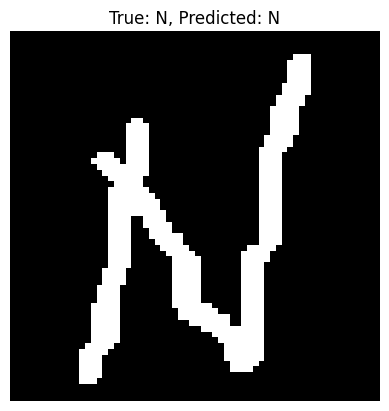

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


67
67


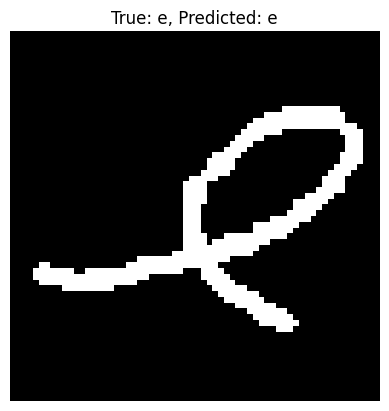

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


22
22


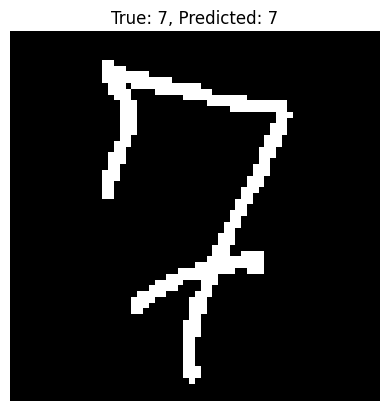

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


53
84


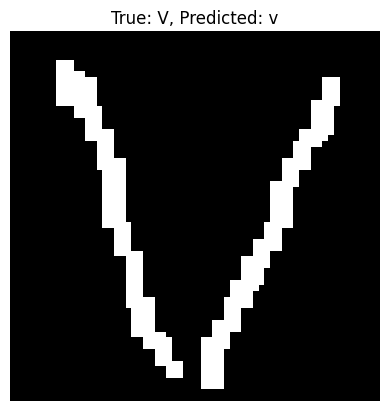

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


63
63


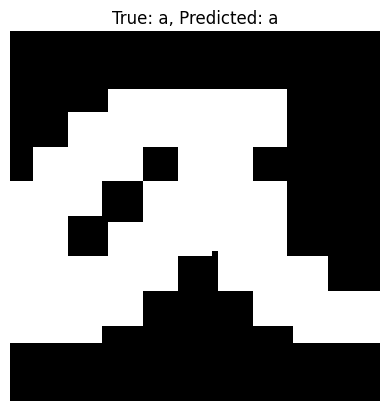

In [14]:
import matplotlib.pyplot as plt
import torch

# Function to display an image and its labels
def show_sample(image, true_label, predicted_label):

    # The .permute call is required to transpose the image. We receive a shape (3, 64, 64) here
    # but .imshow() expects a shape with the channels at the end, like (64, 64, 3)
    image = image.permute(1, 2, 0)
    image = image.cpu().squeeze().numpy()  # Convert to 2D array for display
    plt.imshow(image)
    print(true_label)
    print(predicted_label)
    plt.title(f"True: {unipen_code_to_char(true_label)}, Predicted: {unipen_code_to_char(predicted_label)}")  
    plt.axis('off')
    plt.show()

# Run inference and display samples
model.eval()
num_samples_to_show = 5
shown_samples = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images)
        print(outputs)
        print(outputs.shape)
        probs, predicted = torch.max(outputs, 1)

        for i in range(len(images)):
            if shown_samples >= num_samples_to_show:
                break
            true_label = labels[i].item()
            predicted_label = predicted[i].item()
            # Shift by -1 to match a=1, ..., z=26 in EMNIST "letters"
            show_sample(images[i], true_label, predicted_label )
            shown_samples += 1
        
        if shown_samples >= num_samples_to_show:
            break

In [15]:
from torch import nn

# Get the activation at the penultimate layer

# Interestingly, this is the final non-flat layer 512x7x7
# when I would have expected it to be the final dense layer
# right before the Softmax (4094 -> #numclass)
embedding_model = nn.Sequential(*list(model.children())[:-1])

# Run inference and display samples
embedding_model.eval()
num_samples_to_show = 5
shown_samples = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = embedding_model(images)
        
        print(outputs.shape)
        break
        

torch.Size([16, 512, 7, 7])


In [16]:
#| hide
import nbdev; nbdev.nbdev_export()